In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fetching the Dataset

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# ! cp /content/drive/MyDrive/PKG/dataset.zip Dataset.zip

In [ ]:
!pip install gdown -q
!gdown 170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U

Downloading...
From (original): https://drive.google.com/uc?id=170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U
From (redirected): https://drive.google.com/uc?id=170KlFsiS5ftrHCoNbmc3tvV77ZxYzI0U&confirm=t&uuid=a566c65a-7db2-4388-be25-10bcadc89eca
To: /content/dataset.zip
100% 276M/276M [00:02<00:00, 98.7MB/s]


In [ ]:
! unzip -q dataset.zip

# Importing Dependencies

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    InputLayer,
    Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve
)
import joblib
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# Visualization
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Constants

In [ ]:
BATCH_SIZE = 512
IMAGE_SIZE = 144
CHANNELS = 3
EPOCHS = 50
PATH = 'dataset/'

# Importing data into a TensorFlow dataset object

We will use the `image_dataset_from_directory` API to load all images into a TensorFlow dataset. [Link to the documentation](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory)

In [ ]:
train_ds = image_dataset_from_directory(
    PATH + '/train',
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    PATH + '/test',
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 56704 files belonging to 5 classes.
Found 24510 files belonging to 5 classes.


In [ ]:
class_names = train_ds.class_names
class_names

['CBFB_MYH11', 'NPM1', 'Normal', 'PML_RARA', 'RUNX1_RUNX1T1']

# Visualizing the first batch of images.

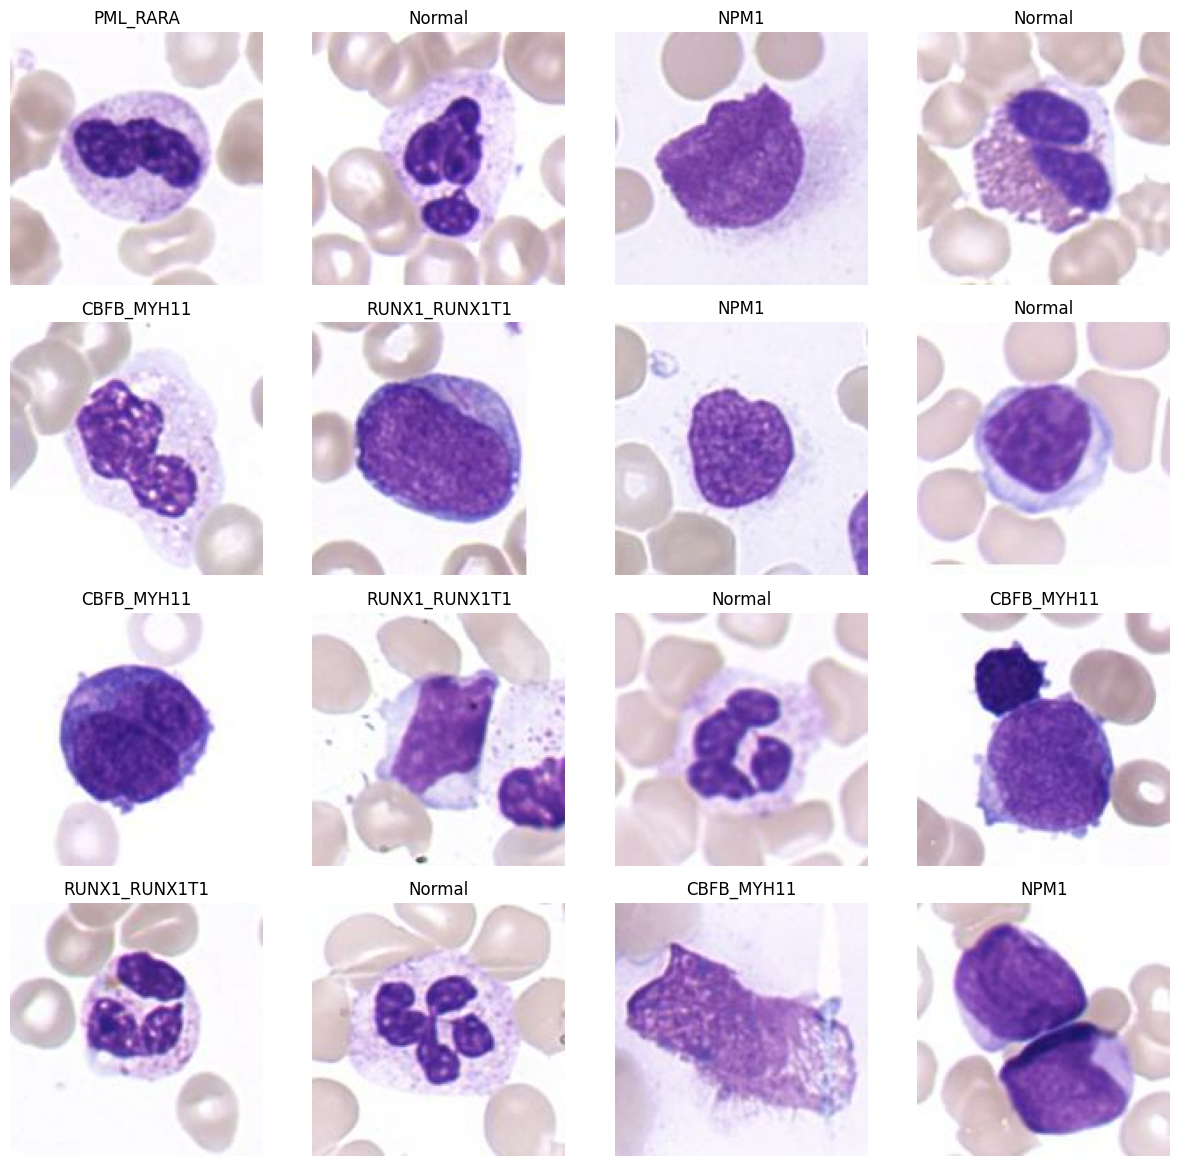

In [ ]:
plt.figure(figsize=(12, 12))
for batch_images, batch_labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(batch_images[i].numpy().astype("uint8"))
        plt.title(class_names[batch_labels[i]])
        plt.tight_layout()
        plt.axis("off")


# Spliting Training and Validation Set

In [ ]:
TRAIN_SIZE, VALIDATION_SIZE= 0.9, 0.1

In [ ]:
train_batch = int(len(train_ds) * TRAIN_SIZE)
train_data = train_ds.take(train_batch)

In [ ]:
val_batch = int(len(train_ds) * VALIDATION_SIZE)
validation_data = train_ds.skip(train_batch).take(val_batch)

# Building Model

## Resizing and Normalization Layer

In [ ]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

## Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.2),
  layers.RandomFlip(seed = 42)
])

## Applying Data Augmentation to Train Dataset

In [ ]:
train_data = train_data.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

## Model Architecture

In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)
inputs = Input(shape=input_shape)

# ResNet50
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs,
    pooling='avg'
)

base_model.trainable = False

x = base_model.output
x = Dense(units=128, activation='relu')(x)
outputs = Dense(n_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 144, 144, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 150, 150, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 72, 72, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 72, 72, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 72, 72, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 74, 74, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 36, 36, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 36, 36, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 36, 36, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 36, 36, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 36, 36, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 36, 36, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 36, 36, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 36, 36, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 36, 36, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

We use `adam` Optimizer, `SparseCategoricalCrossentropy` for losses, `accuracy` as a metric

In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']
)

Creating a checkpoint to save the model with the best score.

In [ ]:
callback = [
    tf.keras.callbacks.ModelCheckpoint(filepath='model.keras', monitor="val_accuracy")
]

## Training

In [ ]:
history = model.fit(
    train_data,
    batch_size = BATCH_SIZE,
    validation_data = validation_data,
    verbose = 1,
    epochs = EPOCHS,
    # epochs = 1,
    callbacks = callback
)

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 230s 2s/step - accuracy: 0.3447 - loss: 1.5192 - val_accuracy: 0.4705 - val_loss: 1.2636
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.4828 - loss: 1.2415 - val_accuracy: 0.5076 - val_loss: 1.1930
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.5091 - loss: 1.1897 - val_accuracy: 0.5339 - val_loss: 1.1326
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.5328 - loss: 1.1524 - val_accuracy: 0.5366 - val_loss: 1.1307
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.5498 - loss: 1.1228 - val_accuracy: 0.5563 - val_loss: 1.1039
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.5552 - loss: 1.1070 - val_accuracy: 0.5749 - val_loss: 1.0586
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.5649 - loss: 1.0871 - val_accuracy: 0.5666 - val_loss: 1.0696
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.5751 - loss: 1.0702 - val_accuracy: 0.5788 - v

## Loading Model

In [ ]:
model = load_model('model.keras')

# Evaluation

### Predict

In [ ]:
all_predictions = []
all_labels = []
for images, labels in tqdm(test_ds):
    predictions = model.predict(images, verbose = 0)
    predicted_classes = np.argmax(predictions, axis=1)
    all_predictions.extend(predicted_classes)
    all_labels.extend(labels.numpy())

100%|██████████| 48/48 [01:04<00:00,  1.35s/it]


### Metrices

In [ ]:
accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')

print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Recall: ", recall)
print("Precision: ", precision)

Accuracy:  0.5461444308445532
F1 Score:  0.5369026891681944
Recall:  0.5461444308445532
Precision:  0.5356076374911842


### Confusion Matrix

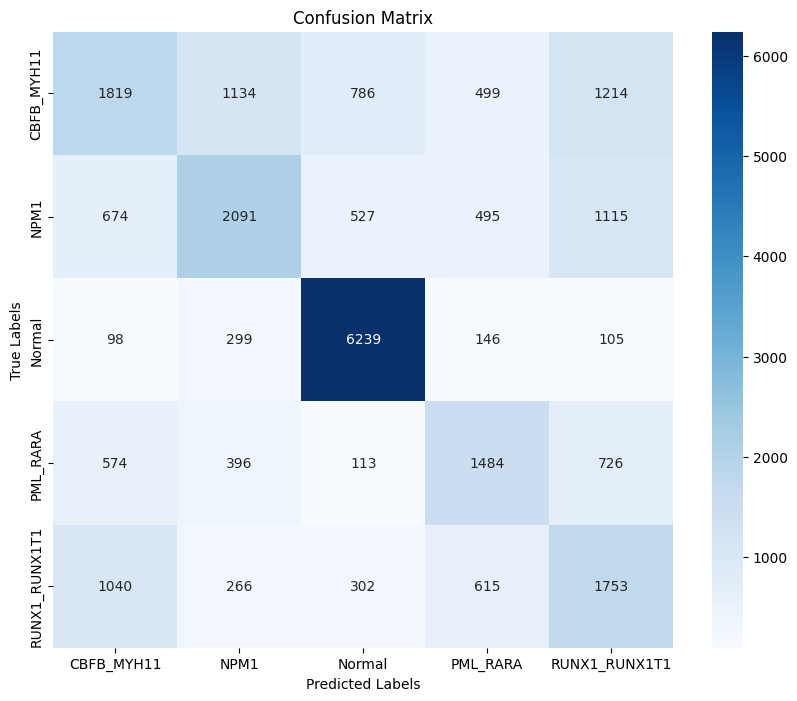

In [ ]:
conf_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix.png', dpi = 300)
plt.show()


## Accuracy and Loss Curves

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

from scipy.ndimage import gaussian_filter1d

sacc = gaussian_filter1d(acc, sigma=2)
sval_acc = gaussian_filter1d(val_acc, sigma=2)

sloss = gaussian_filter1d(loss, sigma=2)
sval_loss = gaussian_filter1d(val_loss, sigma=2)

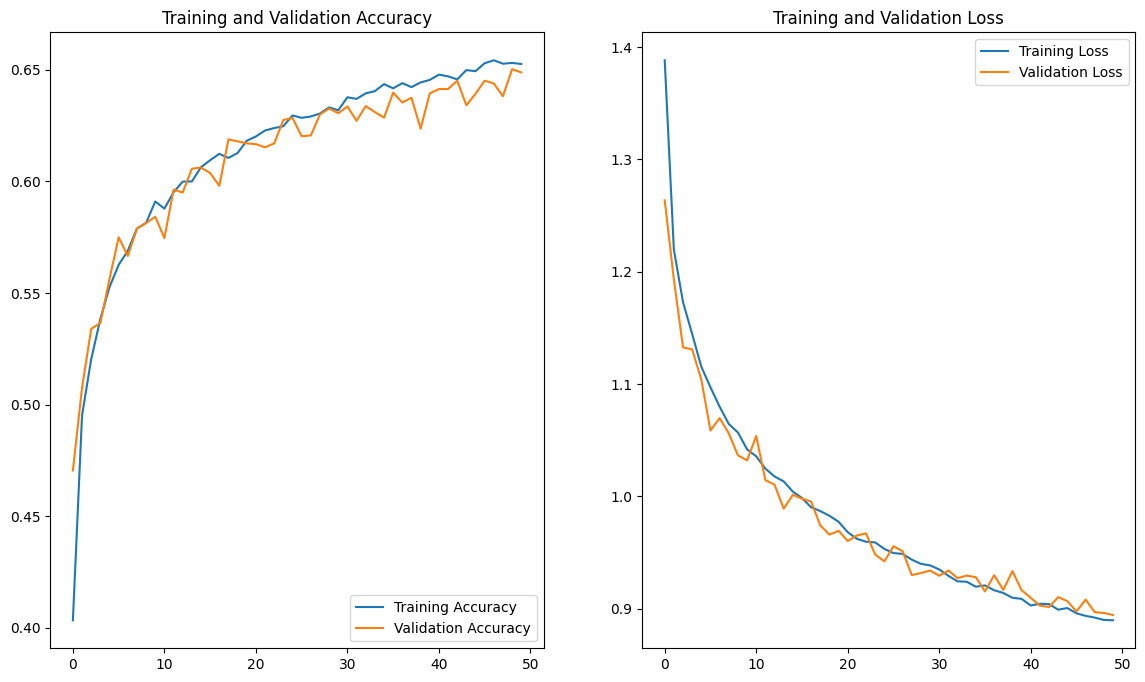

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('curves.png', dpi = 300)
plt.show()

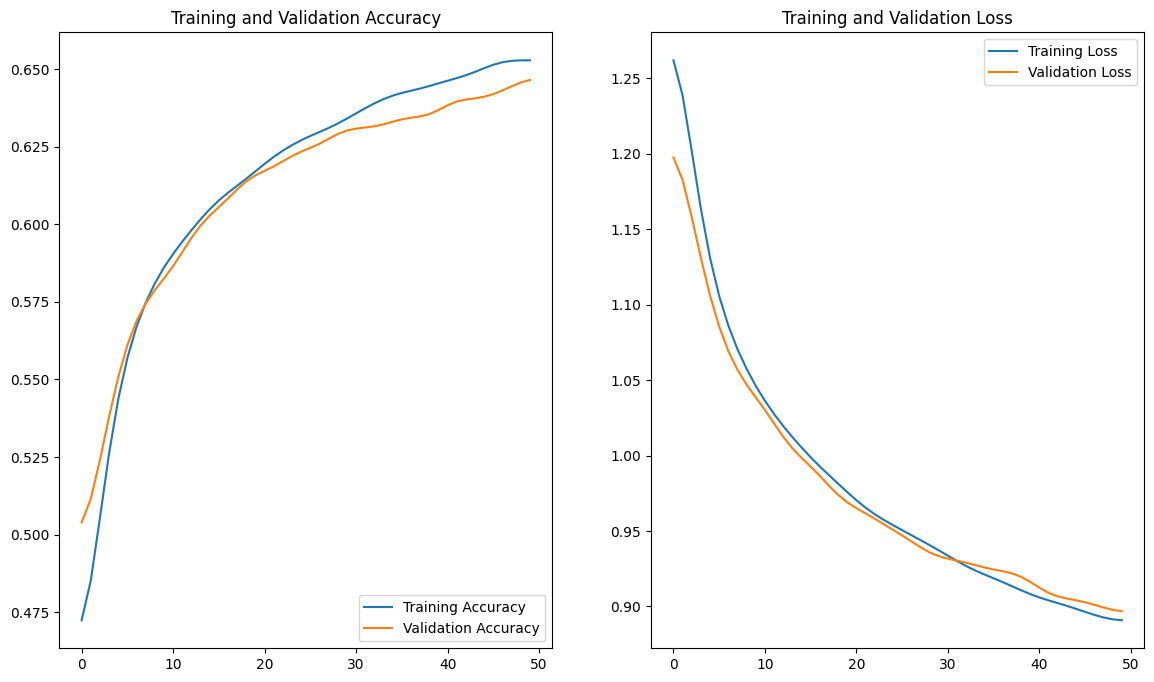

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), sacc, label='Training Accuracy')
plt.plot(range(EPOCHS), sval_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), sloss, label='Training Loss')
plt.plot(range(EPOCHS), sval_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('smoothed curves.png', dpi = 300)
plt.show()

# Inference



## Inference Function

In [ ]:
def predict(model, image):
    img_array = tf.keras.preprocessing.image.img_to_array(image.numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose = 0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

## Running Inference

<Figure size 640x480 with 0 Axes>

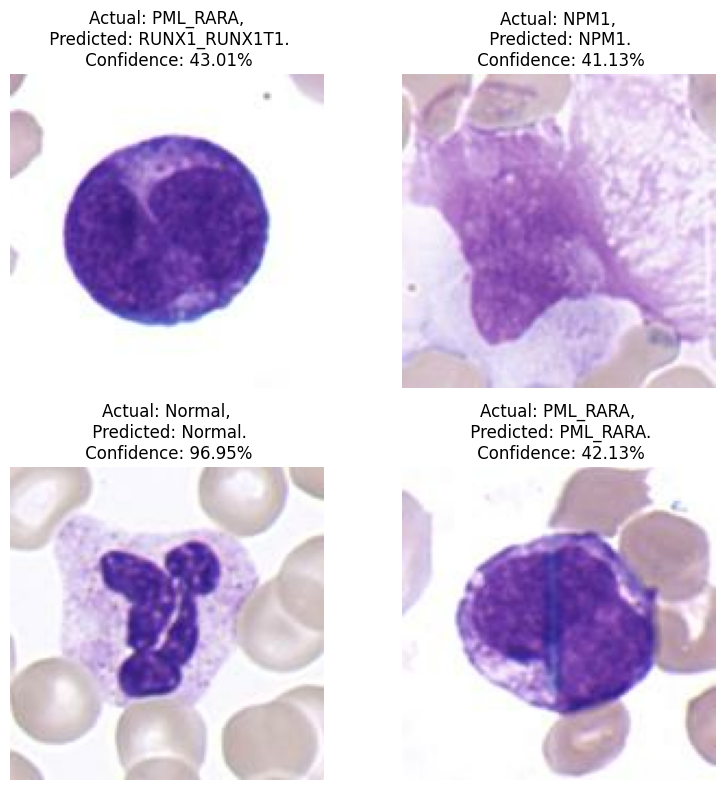

In [ ]:
plt.clf()
plt.figure(figsize=(8, 8))
for images, labels in test_ds.take(6):
    for i in range(4):
        ax = plt.subplot(2, 2, i + 1)
        if i < len(images):
            ax.imshow(images[i].numpy().astype("uint8"))

            predicted_class, confidence = predict(model, images[i])
            actual_class = class_names[labels[i]]

            ax.set_title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
            ax.axis("off")
plt.tight_layout()
plt.show()


# Optional

In [ ]:
!cp model.keras /content/drive/MyDrive/Final/models/resnet.keras